# EmoPairCompete — LOSO Cross-Validation Notebook

This notebook implements **Leave-One-Subject-Out (LOSO) cross-validation**

- **CV split:** `Individual` (LOSO)
- **Representation:** within-subject normalization of physiological features is applied **separately inside each fold** to reduce baseline effects.
- **Cluster selection:** automatic by **BIC** on the training fold, or optional **fixed `k`**
- **Primary external metric:** **NMI** between predicted clusters and held-out subject phase labels
- By default this notebook uses the same broad settings as the exploratory project work:
  - `PCA_VARIANCE_THRESHOLD = 0.80`
  - `GMM_COVARIANCE_TYPE = "diag"`


In [7]:
from pathlib import Path
import sys
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score
from typing import Optional

warnings.filterwarnings("ignore")

# Resolve repository root and ensure src is importable from this notebook.
cwd = Path.cwd()
if (cwd / "src").exists():
    REPO_ROOT = cwd
elif (cwd.parent / "src").exists():
    REPO_ROOT = cwd.parent
else:
    raise FileNotFoundError("Could not locate repository root containing src/")

src_path = str(REPO_ROOT / "src")
if src_path not in sys.path:
    sys.path.append(src_path)

REPO_ROOT


PosixPath('/Users/jiji/Documents/02582_Computational_Data_Analysis/case_II/02582_CDA_Case2')

## Settings

- `FIXED_K = None` → choose `k` automatically by **BIC** on each training fold
- `FIXED_K = 2` or `FIXED_K = 3` → force a fixed number of clusters
- `PCA_VARIANCE_THRESHOLD = 0.80` or `0.90`
- `GMM_COVARIANCE_TYPE = "diag"` or `"full"`

By default the data path points to a **sibling folder**:
`REPO_ROOT.parent / "HR_data_2" / "HR_data_2.csv"`


In [4]:
# =========================
# LOSO SETTINGS
# =========================

DATA_PATH = REPO_ROOT.parent / "data" / "HR_data_2.csv"
OUTPUT_DIR = REPO_ROOT / "outputs_jawhara_loso"

PHYSIOLOGICAL_PREFIXES = ("HR_", "EDA_", "TEMP_")
GROUP_COLUMN = "Individual"
PHASE_COLUMN = "Phase"

PCA_VARIANCE_THRESHOLD = 0.80
K_MIN = 1
K_MAX = 8
GMM_N_INIT = 10
GMM_COVARIANCE_TYPE = "diag"
RANDOM_STATE = 42

# Set to None for automatic BIC-based selection.
# Set to an integer like 2 or 3 for a fixed-k sensitivity run.
FIXED_K = None

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "figures").mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "results").mkdir(parents=True, exist_ok=True)

print("DATA_PATH:", DATA_PATH)
print("Exists?   ", DATA_PATH.exists())
print("OUTPUT_DIR:", OUTPUT_DIR)


DATA_PATH: /Users/jiji/Documents/02582_Computational_Data_Analysis/case_II/data/HR_data_2.csv
Exists?    True
OUTPUT_DIR: /Users/jiji/Documents/02582_Computational_Data_Analysis/case_II/02582_CDA_Case2/outputs_jawhara_loso


In [5]:
# =========================
# Load dataset and select physiological features
# =========================

df = pd.read_csv(DATA_PATH)

feature_cols = [
    c for c in df.columns
    if c.startswith(PHYSIOLOGICAL_PREFIXES)
]

required_cols = [GROUP_COLUMN, PHASE_COLUMN]
missing_required = [c for c in required_cols if c not in df.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

if len(feature_cols) == 0:
    raise ValueError("No physiological feature columns found.")

print("Dataset shape:", df.shape)
print("Number of physiological feature columns:", len(feature_cols))
print("First 10 feature columns:", feature_cols[:10])

print("\nPhase counts:")
print(df[PHASE_COLUMN].value_counts(dropna=False))

print("\nGroup count (Individuals):", df[GROUP_COLUMN].nunique())


Dataset shape: (312, 71)
Number of physiological feature columns: 51
First 10 feature columns: ['HR_TD_Mean', 'HR_TD_Median', 'HR_TD_std', 'HR_TD_Min', 'HR_TD_Max', 'HR_TD_AUC', 'HR_TD_Kurtosis', 'HR_TD_Skew', 'HR_TD_Slope_min', 'HR_TD_Slope_max']

Phase counts:
Phase
phase3    104
phase2    104
phase1    104
Name: count, dtype: int64

Group count (Individuals): 26


In [8]:
# =========================
# Helper functions
# =========================

def zscore_within_groups(frame: pd.DataFrame, feature_columns: list[str], group_column: str) -> pd.DataFrame:
    """Within-group z-score normalization.

    This is done separately for each fold. For the held-out subject, normalization
    uses only that subject's own rows, which is acceptable for offline evaluation.
    """
    out = frame.copy()

    def _zscore(series: pd.Series) -> pd.Series:
        std = series.std(ddof=0)
        if pd.isna(std) or std == 0:
            return pd.Series(np.zeros(len(series)), index=series.index)
        return (series - series.mean()) / std

    out[feature_columns] = (
        out.groupby(group_column)[feature_columns]
           .transform(_zscore)
    )
    return out


def fit_pca_train_transform_test(
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    variance_threshold: float,
    random_state: int = 42,
):
    """Fit PCA on train only, then transform train and test."""
    pca_full = PCA(random_state=random_state)
    Z_train_full = pca_full.fit_transform(X_train)
    Z_test_full = pca_full.transform(X_test)

    cumvar = np.cumsum(pca_full.explained_variance_ratio_)
    n_components = int(np.searchsorted(cumvar, variance_threshold) + 1)

    Z_train = Z_train_full[:, :n_components]
    Z_test = Z_test_full[:, :n_components]

    variance_table = pd.DataFrame({
        "component": np.arange(1, len(cumvar) + 1),
        "explained_variance_ratio": pca_full.explained_variance_ratio_,
        "cumulative_explained_variance": cumvar,
    })

    return pca_full, Z_train, Z_test, n_components, variance_table


def evaluate_gmm_candidates_train_only(
    Z_train: np.ndarray,
    k_min: int,
    k_max: int,
    covariance_type: str,
    random_state: int,
    n_init: int,
) -> pd.DataFrame:
    """Evaluate GMM candidates by AIC/BIC on the training fold only."""
    rows = []
    for k in range(k_min, k_max + 1):
        try:
            gmm = GaussianMixture(
                n_components=k,
                covariance_type=covariance_type,
                random_state=random_state,
                n_init=n_init,
            )
            gmm.fit(Z_train)
            rows.append({
                "k": k,
                "aic": gmm.aic(Z_train),
                "bic": gmm.bic(Z_train),
            })
        except Exception as exc:
            rows.append({
                "k": k,
                "aic": np.nan,
                "bic": np.nan,
            })
            print(f"Warning: GMM failed for k={k}: {exc}")
    scores = pd.DataFrame(rows)
    return scores


def select_k(scores: pd.DataFrame, fixed_k: Optional[int] = None) -> int:
    """Choose k either manually or by BIC minimum."""
    if fixed_k is not None:
        return int(fixed_k)

    valid = scores.dropna(subset=["bic"]).copy()
    if valid.empty:
        raise RuntimeError("No valid GMM candidates were fit.")
    return int(valid.loc[valid["bic"].idxmin(), "k"])


def fit_predict_gmm(
    Z_train: np.ndarray,
    Z_test: np.ndarray,
    k: int,
    covariance_type: str,
    random_state: int,
    n_init: int,
):
    """Fit GMM on train and predict labels for train/test."""
    gmm = GaussianMixture(
        n_components=k,
        covariance_type=covariance_type,
        random_state=random_state,
        n_init=n_init,
    )
    gmm.fit(Z_train)
    train_labels = gmm.predict(Z_train)
    test_labels = gmm.predict(Z_test)
    return gmm, train_labels, test_labels


def fit_fold(train_df: pd.DataFrame, test_df: pd.DataFrame) -> dict:
    """Run one LOSO fold without leakage."""
    # 1) Within-subject normalization inside fold
    train_norm = zscore_within_groups(train_df, feature_cols, GROUP_COLUMN)
    test_norm = zscore_within_groups(test_df, feature_cols, GROUP_COLUMN)

    # 2) Fit imputer on training fold only
    imputer = SimpleImputer(strategy="median")
    X_train = pd.DataFrame(
        imputer.fit_transform(train_norm[feature_cols]),
        columns=feature_cols,
        index=train_norm.index,
    )
    X_test = pd.DataFrame(
        imputer.transform(test_norm[feature_cols]),
        columns=feature_cols,
        index=test_norm.index,
    )

    # 3) Fit PCA on training fold only
    pca, Z_train, Z_test, n_components, variance_table = fit_pca_train_transform_test(
        X_train=X_train,
        X_test=X_test,
        variance_threshold=PCA_VARIANCE_THRESHOLD,
        random_state=RANDOM_STATE,
    )

    # 4) Select k on training fold only
    scores = evaluate_gmm_candidates_train_only(
        Z_train=Z_train,
        k_min=K_MIN,
        k_max=K_MAX,
        covariance_type=GMM_COVARIANCE_TYPE,
        random_state=RANDOM_STATE,
        n_init=GMM_N_INIT,
    )

    final_k = select_k(scores=scores, fixed_k=FIXED_K)

    # 5) Fit final GMM on training fold only, predict on held-out subject
    gmm, train_labels, test_labels = fit_predict_gmm(
        Z_train=Z_train,
        Z_test=Z_test,
        k=final_k,
        covariance_type=GMM_COVARIANCE_TYPE,
        random_state=RANDOM_STATE,
        n_init=GMM_N_INIT,
    )

    # 6) External evaluation on the held-out subject only
    y_test = test_df[PHASE_COLUMN].to_numpy()
    nmi = normalized_mutual_info_score(y_test, test_labels)
    ari = adjusted_rand_score(y_test, test_labels)

    return {
        "scores": scores,
        "final_k": final_k,
        "n_components": n_components,
        "nmi": nmi,
        "ari": ari,
        "test_labels": test_labels,
        "test_phases": y_test,
        "test_index": test_df.index.to_numpy(),
        "variance_table": variance_table,
    }


## Run LOSO CV

This loop leaves out one `Individual` at a time.

For each fold:
1. normalize within subject
2. fit imputer on train only
3. fit PCA on train only
4. choose `k` on train only (or use fixed `k`)
5. fit GMM on train only
6. evaluate on the held-out subject


In [10]:
# =========================
# LOSO CV
# =========================

logo = LeaveOneGroupOut()
groups = df[GROUP_COLUMN]

fold_rows = []
all_test_predictions = []
all_test_truth = []
all_scores = []

for fold_idx, (train_idx, test_idx) in enumerate(logo.split(df, groups=groups), start=1):
    train_df = df.iloc[train_idx].copy()
    test_df = df.iloc[test_idx].copy()

    held_out_group = test_df[GROUP_COLUMN].iloc[0]
    result = fit_fold(train_df, test_df)

    fold_rows.append({
        "fold": fold_idx,
        "held_out_individual": held_out_group,
        "n_train": len(train_df),
        "n_test": len(test_df),
        "selected_k": result["final_k"],
        "selected_pca_components": result["n_components"],
        "test_nmi": result["nmi"],
        "test_ari": result["ari"],
    })

    score_table = result["scores"].copy()
    score_table["fold"] = fold_idx
    score_table["held_out_individual"] = held_out_group
    all_scores.append(score_table)

    pred_df = pd.DataFrame({
        "index": result["test_index"],
        "fold": fold_idx,
        "held_out_individual": held_out_group,
        "true_phase": result["test_phases"],
        "predicted_cluster": result["test_labels"],
    })
    all_test_predictions.append(pred_df)

fold_results = pd.DataFrame(fold_rows)
candidate_scores = pd.concat(all_scores, ignore_index=True)
test_predictions = pd.concat(all_test_predictions, ignore_index=True)

print("LOSO completed.")
print("\nFold-level results:")
display(fold_results.head())

print("\nSummary:")
display(fold_results[["test_nmi", "test_ari", "selected_k", "selected_pca_components"]].agg(["mean", "std", "min", "max"]))


LOSO completed.

Fold-level results:


,fold,held_out_individual,n_train,n_test,selected_k,selected_pca_components,test_nmi,test_ari
0,1,1,300,12,1,14,0.000000,0.000000
1,2,2,300,12,2,14,0.033356,-0.090652
2,3,3,300,12,2,14,0.000000,-0.137931
3,4,4,300,12,2,14,0.293282,0.158640
4,5,5,300,12,2,14,0.033356,-0.090652



Summary:


,test_nmi,test_ari,selected_k,selected_pca_components
mean,0.130564,0.010919,2.038462,14.0
std,0.142093,0.130893,0.445490,0.0
min,0.000000,-0.137931,1.000000,14.0
max,0.553208,0.407932,4.000000,14.0


In [11]:
# =========================
# Save fold results
# =========================

results_dir = OUTPUT_DIR / "results"
figures_dir = OUTPUT_DIR / "figures"

fold_results.to_csv(results_dir / "loso_fold_results.csv", index=False)
candidate_scores.to_csv(results_dir / "loso_gmm_candidate_scores.csv", index=False)
test_predictions.to_csv(results_dir / "loso_test_predictions.csv", index=False)

summary = {
    "n_folds": int(len(fold_results)),
    "cv_scheme": "LeaveOneGroupOut",
    "group_column": GROUP_COLUMN,
    "phase_column": PHASE_COLUMN,
    "fixed_k": None if FIXED_K is None else int(FIXED_K),
    "automatic_k_selection": FIXED_K is None,
    "pca_variance_threshold": float(PCA_VARIANCE_THRESHOLD),
    "gmm_covariance_type": GMM_COVARIANCE_TYPE,
    "mean_test_nmi": float(fold_results["test_nmi"].mean()),
    "std_test_nmi": float(fold_results["test_nmi"].std(ddof=1)),
    "mean_test_ari": float(fold_results["test_ari"].mean()),
    "std_test_ari": float(fold_results["test_ari"].std(ddof=1)),
    "mean_selected_k": float(fold_results["selected_k"].mean()),
    "selected_k_counts": fold_results["selected_k"].value_counts().sort_index().to_dict(),
    "mean_selected_pca_components": float(fold_results["selected_pca_components"].mean()),
}

with (results_dir / "loso_summary.json").open("w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

summary


{'n_folds': 26,
 'cv_scheme': 'LeaveOneGroupOut',
 'group_column': 'Individual',
 'phase_column': 'Phase',
 'fixed_k': None,
 'automatic_k_selection': True,
 'pca_variance_threshold': 0.8,
 'gmm_covariance_type': 'diag',
 'mean_test_nmi': 0.13056407677839882,
 'std_test_nmi': 0.14209272681186266,
 'mean_test_ari': 0.010919393651161432,
 'std_test_ari': 0.13089310452480107,
 'mean_selected_k': 2.0384615384615383,
 'selected_k_counts': {1: 1, 2: 24, 4: 1},
 'mean_selected_pca_components': 14.0}

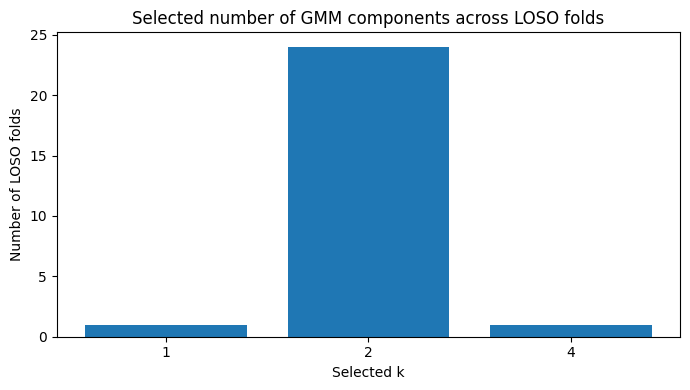

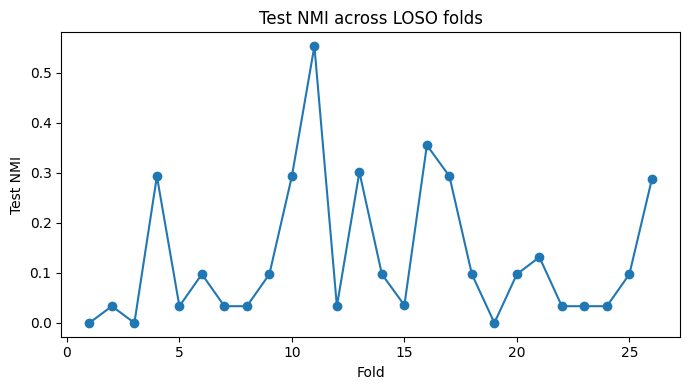

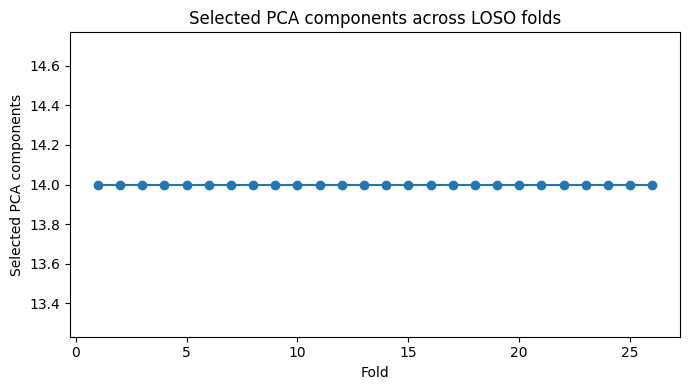

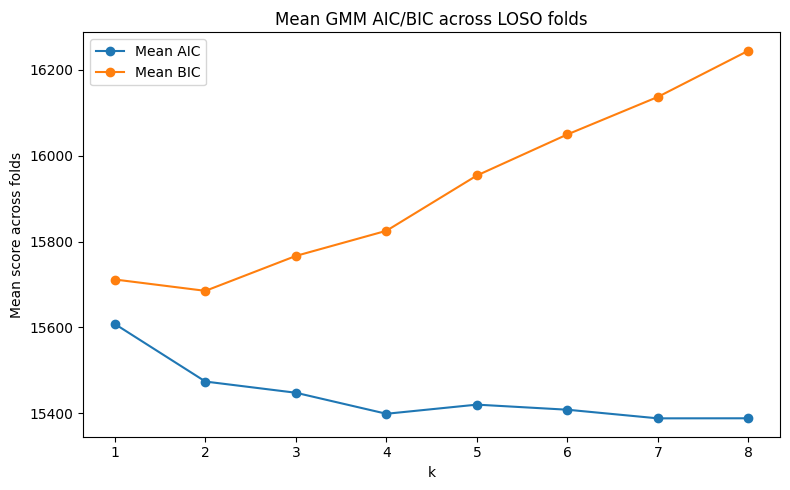

,k,aic,bic
0,1,15607.912550,15711.618460
1,2,15474.098046,15685.213647
2,3,15448.028604,15766.553897
3,4,15399.107936,15825.042921
4,5,15420.372434,15953.717110
5,6,15408.543589,16049.297957
6,7,15388.470236,16136.634296
7,8,15388.594595,16244.168347


In [12]:
# =========================
# Diagnostic plots
# =========================

# 1) Selected k across folds
k_counts = fold_results["selected_k"].value_counts().sort_index()

plt.figure(figsize=(7, 4))
plt.bar(k_counts.index.astype(str), k_counts.values)
plt.xlabel("Selected k")
plt.ylabel("Number of LOSO folds")
plt.title("Selected number of GMM components across LOSO folds")
plt.tight_layout()
plt.savefig(figures_dir / "loso_selected_k_counts.png", dpi=200)
plt.show()

# 2) NMI across folds
plt.figure(figsize=(7, 4))
plt.plot(fold_results["fold"], fold_results["test_nmi"], marker="o")
plt.xlabel("Fold")
plt.ylabel("Test NMI")
plt.title("Test NMI across LOSO folds")
plt.tight_layout()
plt.savefig(figures_dir / "loso_test_nmi_by_fold.png", dpi=200)
plt.show()

# 3) PCA components across folds
plt.figure(figsize=(7, 4))
plt.plot(fold_results["fold"], fold_results["selected_pca_components"], marker="o")
plt.xlabel("Fold")
plt.ylabel("Selected PCA components")
plt.title("Selected PCA components across LOSO folds")
plt.tight_layout()
plt.savefig(figures_dir / "loso_selected_pca_components_by_fold.png", dpi=200)
plt.show()

# 4) Mean AIC/BIC across folds for each k
score_summary = (
    candidate_scores.groupby("k")[["aic", "bic"]]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 5))
plt.plot(score_summary["k"], score_summary["aic"], marker="o", label="Mean AIC")
plt.plot(score_summary["k"], score_summary["bic"], marker="o", label="Mean BIC")
plt.xlabel("k")
plt.ylabel("Mean score across folds")
plt.title("Mean GMM AIC/BIC across LOSO folds")
plt.legend()
plt.tight_layout()
plt.savefig(figures_dir / "loso_mean_aic_bic_by_k.png", dpi=200)
plt.show()

display(score_summary)


## Interpretation guide

A few useful reading rules:

- **Very low mean NMI / ARI** → the clusters do not align strongly with the known phase labels on held-out subjects.
- **Selected `k` varies a lot across folds** → latent structure is unstable across subjects.
- **Selected `k = 1` often** → the data may not support a strong multi-cluster partition under the chosen settings.
- **Fixed `k=2` or `k=3` runs** can still be useful as **sensitivity analyses**, even when automatic model selection is conservative.

### Recommended next experiments
1. Run with `FIXED_K = None` and `GMM_COVARIANCE_TYPE = "diag"`
2. Run again with `FIXED_K = 2`
3. Run again with `FIXED_K = 3`
4. Compare:
   - mean test NMI
   - selected `k` stability
   - PCA components selected across folds
